In [ ]:
import re
import nltk

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
from google.colab import files
import os

uploaded_files = files.upload()
documents = []
filenames = []

for filename in uploaded_files.keys():
    with open(filename, 'r', encoding='utf-8') as f:
        documents.append(f.read())
        filenames.append(filename)

Saving environment_048.txt to environment_048.txt
Saving environment_049.txt to environment_049.txt
Saving environment_058.txt to environment_058.txt
Saving environment_059.txt to environment_059.txt
Saving environment_060.txt to environment_060.txt
Saving environment_062.txt to environment_062.txt
Saving environment_063.txt to environment_063.txt
Saving environment_064.txt to environment_064.txt
Saving environment_065.txt to environment_065.txt
Saving environment_066.txt to environment_066.txt
Saving environment_067.txt to environment_067.txt
Saving environment_070.txt to environment_070.txt
Saving environment_071.txt to environment_071.txt
Saving environment_072.txt to environment_072.txt
Saving environment_073.txt to environment_073.txt
Saving environment_074.txt to environment_074.txt
Saving environment_076.txt to environment_076.txt
Saving environment_077.txt to environment_077.txt
Saving environment_088.txt to environment_088.txt
Saving environment_089.txt to environment_089.txt


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer(stop_words='english') # Moved vectorizer to global scope

def rank_documents_by_topic(documents, topic):
    # Filter out empty documents
    documents = [doc for doc in documents if doc.strip()]

    if not documents:
        raise ValueError("No valid (non-empty) documents provided.")

    tfidf_matrix = vectorizer.fit_transform([topic] + documents)

    if tfidf_matrix.shape[0] < 2:
        raise ValueError("TF-IDF matrix has insufficient documents to compare.")

    cosine_sim = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:]).flatten()
    ranked_indices = cosine_sim.argsort()[::-1]
    return ranked_indices, cosine_sim

In [ ]:
article_text = "just what is agility in the context of software engineering work? ivar jacobson [jac02a] provides a useful discussion: agility  has become today’s buzzword when describing a modern software process. everyone is agile. an agile team is a nimble team able to appropriately respond to changes. change is what software development is very much about. changes in the software being built, changes to the team members, changes because of new technology, changes of all kinds that may have an impact on the product they build or the project that creates the product. support for changes should be built-in everything we do in software, something we embrace because it is the heart and soul of software. an agile team recognizes that software is developed by individuals working in teams and that the skills of these people, their ability to collaborate is at the core for the success of the project.in jacobson’s view, the pervasiveness of change is the primary driver for agility. software engineers must be quick on their feet if they are to accommodate the rapid changes that jacobson describes.  but agility is more than an effective response to change. it also encompasses the philosophy espoused in the manifesto noted at the beginning of this chapter. it encourages team structures and attitudes that make communication (among team members, between technologists and business people, between software engineers and their managers) more facile. it emphasizes rapid delivery of operational software and deemphasizes the importance of intermediate work products (not always a good thing); it adopts the customer as a part of the development team and works to eliminate the “us and them” attitude that continues to pervade many software projects; it recognizes that planning in an uncertain world has its limits and that a project plan must be ﬂ exible.  agility can be applied to any software process. however, to accomplish this, it is essential that the process be designed in a way that allows the project team to adapt tasks and to streamline them, conduct planning in a way that understands the ﬂ uidity of an agile development approach, eliminate all but the most essential work products and keep them lean, and emphasize an incremental delivery strategy that gets working software to the customer as rapidly as feasible for the product type and operational environment."

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import re
import nltk
import heapq

def summarize_text(text, num_sentences=5):
    # Ensure punkt tokenizer is loaded
    try:
        nltk.data.find('tokenizers/punkt')
    except LookupError:
        nltk.download('punkt')

    # Ensure punkt_tab is loaded
    try:
        nltk.data.find('tokenizers/punkt_tab')
    except LookupError:
        nltk.download('punkt_tab')

    # Ensure stopwords are loaded
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        nltk.download('stopwords')

    # Clean and tokenize
    clean_text = re.sub('[^a-zA-Z]', ' ', text.lower())
    clean_text = re.sub('\s+', ' ', clean_text)

    sentence_list = nltk.sent_tokenize(text)
    stopwords = nltk.corpus.stopwords.words('english')

    # Frequency table
    word_frequencies = {}
    for word in nltk.word_tokenize(clean_text):
        if word not in stopwords:
            word_frequencies[word] = word_frequencies.get(word, 0) + 1

    maximum_frequency = max(word_frequencies.values(), default=1)
    for word in word_frequencies:
        word_frequencies[word] /= maximum_frequency

    # Score sentences
    sentence_scores = {}
    for sentence in sentence_list:
        for word in nltk.word_tokenize(sentence.lower()):
            if word in word_frequencies and len(sentence.split()) < 30:
                sentence_scores[sentence] = sentence_scores.get(sentence, 0) + word_frequencies[word]

    # Top sentences
    top_sentences = heapq.nlargest(num_sentences, sentence_scores, key=sentence_scores.get)

    # Format nicely
    formatted_summary = "\n\n".join([f"• {sentence.strip()}" for sentence in top_sentences])
    return formatted_summary

In [ ]:
summarize_text(document_text, num_sentences=5)

NameError: name 'article_text' is not defined

In [ ]:
def generate_combined_summary(topic, documents, filenames, top_n=5):
    ranked_indices, similarities = rank_documents_by_topic(documents, topic)
    print(f"🔍 Topic: {topic}\n")
    print("📄 Top Relevant Document Summaries:\n")

    final_summary = ""
    for i in range(top_n):
        idx = ranked_indices[i]
        print(f"{i+1}. 📘 {filenames[idx]} (Similarity: {similarities[idx]:.2f})")
        summary = summarize_text(documents[idx])
        print(summary)
        print("\n" + "-"*80 + "\n")
        final_summary += summary + " "

    print("\n📝 Combined Summary:\n")
    print(final_summary.strip())

In [ ]:
topic_query = "components of environment"
generate_combined_summary(topic_query, documents, filenames)

🔍 Topic: components of environment

📄 Top Relevant Document Summaries:

1. 📘 environment_002.txt (Similarity: 0.19)
• The global perspective on environment highlights the importance of cultural diversity and international cooperation in addressing shared challenges.

• The concept of sustainable agriculture is fundamental to understanding the broader implications of environment in contemporary society.

• The concept of biodiversity is fundamental to understanding the broader implications of environment in contemporary society.

• The concept of pollution is fundamental to understanding the broader implications of environment in contemporary society.

• The trajectory of environment suggests: The interconnected nature of environmental systems means that changes in one area can have cascading effects throughout the entire ecosystem.

--------------------------------------------------------------------------------

2. 📘 environment_061.txt (Similarity: 0.19)
• Future developments in envi

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer(stop_words='english') # Moved vectorizer to global scope

def rank_documents_by_topic(documents, topic):
    # Filter out empty documents
    documents = [doc for doc in documents if doc.strip()]

    if not documents:
        raise ValueError("No valid (non-empty) documents provided.")

    tfidf_matrix = vectorizer.fit_transform([topic] + documents)

    if tfidf_matrix.shape[0] < 2:
        raise ValueError("TF-IDF matrix has insufficient documents to compare.")

    cosine_sim = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:]).flatten()
    ranked_indices = cosine_sim.argsort()[::-1]
    return ranked_indices, cosine_sim

def generate_combined_summary(topic, documents, filenames, top_n=5):
    ranked_indices, similarities = rank_documents_by_topic(documents, topic)
    print(f"🔍 Topic: {topic}\n")
    print("📄 Top Relevant Document Summaries:\n")

    final_summary = ""
    for i in range(min(top_n, len(ranked_indices))): # Ensure not to exceed the number of documents
        idx = ranked_indices[i]
        print(f"{i+1}. 📘 {filenames[idx]} (Similarity: {similarities[idx]:.2f})")
        summary = summarize_text(documents[idx])
        print(summary)
        print("\n" + "-"*80 + "\n")
        final_summary += summary + " "

    print("\n📝 Combined Summary:\n")
    print(final_summary.strip())


✅ Best Match:
→ Image: /content/drive/MyDrive/Testing/Imges for testing/Envi5.jpg
→ Similarity Score: 0.4083


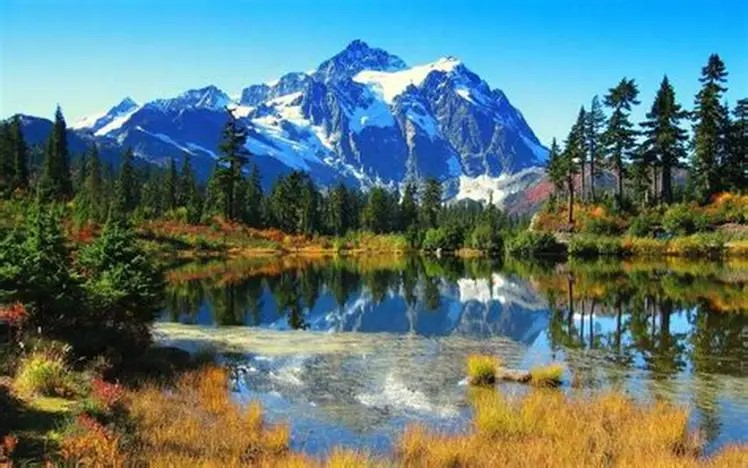

📄 Generated Summary:
A beautiful depiction of a natural environment undisturbed by human activity


In [ ]:
result = generate_combined_summary(
    topic_query="Natural Environment",
    image_dir="/content/drive/MyDrive/Testing/Imges for testing",
    label_dir="/content/drive/MyDrive/Testing/Labels for testing"
)

print("📄 Generated Summary:")
print(result["summary"])

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
from PIL import Image
import os

def generate_combined_summary_image(topic_query, image_dir, label_dir):
    best_score = -1
    best_image_path = None
    best_label_text = ""

    label_texts = []
    label_filenames = []
    for label_file in os.listdir(label_dir):
        if label_file.endswith(".txt"):
            label_path = os.path.join(label_dir, label_file)
            with open(label_path, 'r', encoding='utf-8') as f:
                label_texts.append(f.read().strip())
                label_filenames.append(label_file)

    if not label_texts:
        print("No label files found in the specified directory.")
        return {
            "summary": "",
            "image_path": None,
            "similarity": -1
        }

    # Fit the vectorizer on the topic and all label texts
    corpus = [topic_query] + label_texts
    tfidf_matrix = vectorizer.fit_transform(corpus)

    topic_embedding = tfidf_matrix[0:1]

    for i, label_text in enumerate(label_texts):
        label_embedding = tfidf_matrix[i+1:i+2] # Get the embedding for the current label
        similarity = cosine_similarity(topic_embedding, label_embedding).item()

        if similarity > best_score:
            best_score = similarity
            best_image_path = os.path.join(image_dir, os.path.splitext(label_filenames[i])[0] + ".jpg")
            best_label_text = label_text

    # Display best-matching image
    if best_image_path and os.path.exists(best_image_path):
        print(f"\n✅ Best Match:\n→ Image: {best_image_path}\n→ Similarity Score: {best_score:.4f}")
        # Display image using PIL (Pillow)
        try:
            img = Image.open(best_image_path)
            display(img) # Use display() for Colab
        except Exception as e:
            print(f"Could not display image: {e}")
    elif best_image_path:
        print(f"\n✅ Best Match found, but image file not found:\n→ Expected Image Path: {best_image_path}\n→ Similarity Score: {best_score:.4f}")
        print("→ Label Text:")
        print(best_label_text)
    else:
        print("No relevant documents found.")


    return {
        "summary": best_label_text,
        "image_path": best_image_path,
        "similarity": best_score
    }